# 1. Import Libraries

Our approach in this notebook will be to do some EDA and initial forecasts using the popular econometric model ARIMA. Luckily there's a very powerful tool for python named autoarima which does a ton of EDA for us. We can use this to test for stationarity, differencing, finding the optimal hyperparameters, and determining seasonal decomposition. Since ARIMA is a proven economic metric that works well with autocorrelated features, which is likely most if not all of the economic variables in our gathered dataset.

In [1]:
import pmdarima as pm
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 2. Define Auto Arima Function

Since we'll be running autoarima on all features, let's define a function with some high parameters to search for the optimal metrics on all of our variables using a for loop.

In [2]:
def fit_auto_arima(
    series, 
    m=4,              # Keep frequency specific to data
    seasonal=True,    # Keep seasonality specific to data
    stepwise=False,     # CRUCIAL: Disable stepwise for exhaustive search
    max_p=8,          # INCREASED: Allow higher non-seasonal AR order
    max_q=8,          # INCREASED: Allow higher non-seasonal MA order
    max_P=5,          # INCREASED: Allow higher seasonal AR order
    max_Q=5,          # INCREASED: Allow higher seasonal MA order
    max_order=20,     # INCREASED: Allow higher total order (p+q+P+Q)
    start_p=1,        # Start values are less critical for exhaustive search
    start_q=1,
    start_P=0,
    d=None,           # Let tests determine differencing
    D=None,           # Let tests determine seasonal differencing
    trace=True,       # Keep True to see the (now much longer) trace
    error_action='ignore', # Keep ignoring models that fail
    suppress_warnings=True, # Keep suppressing warnings
    **kwargs          # Allows overriding any default above or adding others like method='powell'
):

    # Call auto_arima with the specified defaults / passed arguments
    model = pm.auto_arima(
        series,
        start_p=start_p, start_q=start_q,
        max_p=max_p, max_q=max_q,
        m=m,
        start_P=start_P,
        seasonal=seasonal,
        d=d,
        D=D,
        trace=trace,
        error_action=error_action,
        suppress_warnings=suppress_warnings,
        stepwise=stepwise,
        **kwargs # Pass any other overrides or extra args
    )

    return model

# 3. Run autoarima on all columns

Here we run autoarima on all the columns using a for loop. Before we do that, we use the Pandas sort function since our main df has missing values.We sort from least to most so we don't delete values for other variables that have less or no missing values before we run autoarima on it.

In [3]:
df = pd.read_csv('DC_Master_Missing.csv', index_col=0, parse_dates=True) 

# Calculate missing values per column
missing_counts = df.isnull().sum()

# Sort columns by missing count (least to most)
print("\nSorting columns")
sorted_columns = missing_counts.sort_values().index.tolist()
print("Pandas Sort Order:", sorted_columns)

# --- Fit AutoARIMA Models ---

fitted_models = {} # Dictionary to store the fitted model for each column

print(f"\nStarting AutoARIMA fitting process for {len(sorted_columns)} columns...")

for col_name in sorted_columns:
    print(f"\nProcessing column: {col_name}")
    
    series = df[col_name]
    
    # Check if the column has any missing values
    train_data = series.dropna()
        
    # Fit the AutoARIMA model
    model = fit_auto_arima(train_data)
        
    print(f"  Successfully fitted ARIMA model for '{col_name}'. Order: {model.order}, Seasonal Order: {model.seasonal_order}")
    # Print summary for each model
    print(model.summary())
    fitted_models[col_name] = model # Store the fitted model

print("\nAutoARIMA fitting process completed.")
print(f"Fitted {sum(1 for m in fitted_models.values() if m is not None)} models.")

# At this point, 'fitted_models' dictionary contains the trained model 
# The next step would be to use these models to forecast and fill NaNs.


Sorting columns
Pandas Sort Order: ['Unemployment_Rate', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'House_Index', 'GDP', 'Population', 'Poverty_Rate', 'Median_Household_Income']

Starting AutoARIMA fitting process for 9 columns...

Processing column: Unemployment_Rate
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=509.230, Time=0.02 sec
 ARIMA(0,0,0)(0,0,1)[4] intercept   : AIC=449.358, Time=0.18 sec
 ARIMA(0,0,0)(0,0,2)[4] intercept   : AIC=442.928, Time=0.12 sec
 ARIMA(0,0,0)(1,0,0)[4] intercept   : AIC=449.056, Time=0.22 sec
 ARIMA(0,0,0)(1,0,1)[4] intercept   : AIC=442.586, Time=0.40 sec
 ARIMA(0,0,0)(1,0,2)[4] intercept   : AIC=444.197, Time=0.74 sec
 ARIMA(0,0,0)(2,0,0)[4] intercept   : AIC=441.762, Time=0.46 sec
 ARIMA(0,0,0)(2,0,1)[4] intercept   : AIC=443.762, Time=0.51 sec
 ARIMA(0,0,0)(2,0,2)[4] intercept   : AIC=444.078, Time=0.67 sec
 ARIMA(0,0,1)(0,0,0)[4] intercept   : AIC=435.560, Time=0.05 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=383.027, Time=0.19 sec
 ARIMA(0,0,1)(0,

# 4. Summarize Optimal Models

So autoarima gave us a lot of preliminary insight on the data. We will eventually formally confirm many of the decisions ARIMA made for us, but for now let's make sure the fitted models are properly stored for us to run forecasts.

In [4]:
print("\nFitted models summary:")
for col_name, model in fitted_models.items():
    print(f"Column: {col_name}, Model Order: {model.order}, Seasonal Order: {model.seasonal_order}")


Fitted models summary:
Column: Unemployment_Rate, Model Order: (2, 0, 1), Seasonal Order: (1, 0, 0, 4)
Column: Interest_Rate, Model Order: (2, 1, 2), Seasonal Order: (0, 0, 0, 4)
Column: Mortgage_Rate, Model Order: (0, 1, 0), Seasonal Order: (0, 0, 0, 4)
Column: CPI, Model Order: (1, 1, 0), Seasonal Order: (1, 0, 1, 4)
Column: House_Index, Model Order: (0, 1, 3), Seasonal Order: (1, 0, 0, 4)
Column: GDP, Model Order: (0, 2, 1), Seasonal Order: (0, 0, 0, 4)
Column: Population, Model Order: (1, 1, 0), Seasonal Order: (0, 0, 1, 4)
Column: Poverty_Rate, Model Order: (2, 1, 0), Seasonal Order: (1, 0, 2, 4)
Column: Median_Household_Income, Model Order: (1, 1, 3), Seasonal Order: (0, 0, 0, 4)


# 5. Forecast and Fill Missing Values 

Now to finish off, we decide to forecast until January 2027 just to give us some leg room on the models we might run next. This would also be useful for recursive forecasting using combined approaches. This is depending on what we find on subsequent models.

In [5]:
# Make a copy of the original DataFrame to fill
df_filled = df.copy()

# Define the final date for forecasting BEFORE reindexing
forecast_end_date = pd.to_datetime('2027-01-01')
original_start_date = df.index.min() # Store original start date

# Reindex df_filled FIRST to ensure it has the full desired index range
print(f"Reindexing DataFrame from {original_start_date.strftime('%Y-%m-%d')} to {forecast_end_date.strftime('%Y-%m-%d')}...")
full_index = pd.date_range(start=original_start_date, end=forecast_end_date, freq='QS')
df_filled = df_filled.reindex(full_index)
print("Reindexing complete.")


for col_name, model in fitted_models.items():
    print(f"\nProcessing column: {col_name}")

    series_original = df[col_name].dropna() # Use original data without NaNs for reference

    last_valid_index = series_original.index.max() # Last date with valid data IN ORIGINAL DF

    # Determine the date from which forecasting should start
    start_forecast_date = last_valid_index + pd.DateOffset(months=3) # Start forecast in the next quarter
    # These are the dates we need to generate predictions for
    forecast_index = pd.date_range(start=start_forecast_date, end=forecast_end_date, freq='QS')
    n_periods_to_forecast = len(forecast_index)

    print(f"  Last valid data at: {last_valid_index.strftime('%Y-%m-%d')}")
    print(f"  Forecasting {n_periods_to_forecast} steps from {start_forecast_date.strftime('%Y-%m-%d')} to {forecast_end_date.strftime('%Y-%m-%d')}")

    # The model forecasts from the point *after* the data it was trained on ends.
    forecast_values = model.predict(n_periods=n_periods_to_forecast)

    # --- Fill the values in df_filled ---
    # Since df_filled was reindexed, these indices should exist (likely with NaNs)
    # Directly assign the forecast values to the corresponding dates in df_filled
    # Ensure forecast_values is treated as a numpy array or list for direct assignment if index alignment issues occur
    if isinstance(forecast_values, pd.Series):
         # If predict returns a Series, ensure its index matches the target dates
         forecast_values.index = forecast_index
    elif isinstance(forecast_values, np.ndarray):
         # If it's an array, convert to Series for easier assignment
         forecast_values = pd.Series(forecast_values, index=forecast_index)

    # Now assign the values
    df_filled.loc[forecast_index, col_name] = forecast_values
    print(f"  Filled {len(forecast_index)} values for {col_name}")


print("\nForecasting and filling process completed.")

# Display the tail of the filled DataFrame to check
print("\nTail of the filled DataFrame:")
print(df_filled.tail(10)) # Show more tail rows to see up to 2027

# Check if any NaNs remain up to the forecast end date
print("\nRemaining NaNs check:")
print(df_filled.loc[:forecast_end_date].isnull().sum())

Reindexing DataFrame from 1990-01-01 to 2027-01-01...
Reindexing complete.

Processing column: Unemployment_Rate
  Last valid data at: 2025-04-01
  Forecasting 7 steps from 2025-07-01 to 2027-01-01
  Filled 7 values for Unemployment_Rate

Processing column: Interest_Rate
  Last valid data at: 2025-04-01
  Forecasting 7 steps from 2025-07-01 to 2027-01-01
  Filled 7 values for Interest_Rate

Processing column: Mortgage_Rate
  Last valid data at: 2025-04-01
  Forecasting 7 steps from 2025-07-01 to 2027-01-01
  Filled 7 values for Mortgage_Rate

Processing column: CPI
  Last valid data at: 2025-01-01
  Forecasting 8 steps from 2025-04-01 to 2027-01-01
  Filled 8 values for CPI

Processing column: House_Index
  Last valid data at: 2024-10-01
  Forecasting 9 steps from 2025-01-01 to 2027-01-01
  Filled 9 values for House_Index

Processing column: GDP
  Last valid data at: 2024-10-01
  Forecasting 9 steps from 2025-01-01 to 2027-01-01
  Filled 9 values for GDP

Processing column: Population


# 6. Visualize Every Forecast And Report Metrics

In order to get an idea of how much error we get from running ARIMA, we're going to visualize and report metrics with 1-8 step forecasts on every variable in our data set. This will also give us a preliminary idea of how well ARIMA performs on our main dependent variable of this project, the MSA housing price index.

### Helper Functions for Metrics

First we begin with our helper functions to help us determine MAPE and directional accuracy.

In [6]:
# Ignore warnings
warnings.filterwarnings("ignore")

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if not np.any(mask): return np.nan
    y_true_masked, y_pred_masked = y_true[mask], y_pred[mask]
    if len(y_true_masked) == 0: return np.nan
    return np.mean(np.abs((y_true_masked - y_pred_masked) / y_true_masked)) * 100

def directional_accuracy(y_true, y_pred, y_hist):
    y_true, y_pred, y_hist = np.array(y_true), np.array(y_pred), np.array(y_hist)
    if len(y_true) < 1 or len(y_true) != len(y_pred) or len(y_true) != len(y_hist): return np.nan
    true_diff = y_true - y_hist
    pred_diff = y_pred - y_hist
    sign_true = np.sign(true_diff)
    sign_pred = np.sign(pred_diff)
    correct_direction = (sign_true == sign_pred)
    correct_direction = correct_direction | ((true_diff == 0) & (pred_diff == 0))
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

### Walk-Forward Validation Setup

In [7]:
n_test_quarters = 36
steps_to_calculate = list(range(1, 9)) # Calculate metrics for steps 1 through 8
steps_to_plot = [1, 4, 8]             # Only plot steps 1, 4, and 8
max_steps = max(steps_to_calculate)   # Max steps needed for prediction
all_column_metrics = {}
all_column_predictions = {}

### Main Loop over Columns


--- Processing Column: Unemployment_Rate ---
  Train Period: 1990-01-01 to 2016-04-01
  Test Period : 2016-07-01 to 2025-04-01
  Starting walk-forward loop...
  Walk-forward loop finished.
  Calculating metrics...
  Generating visualization...


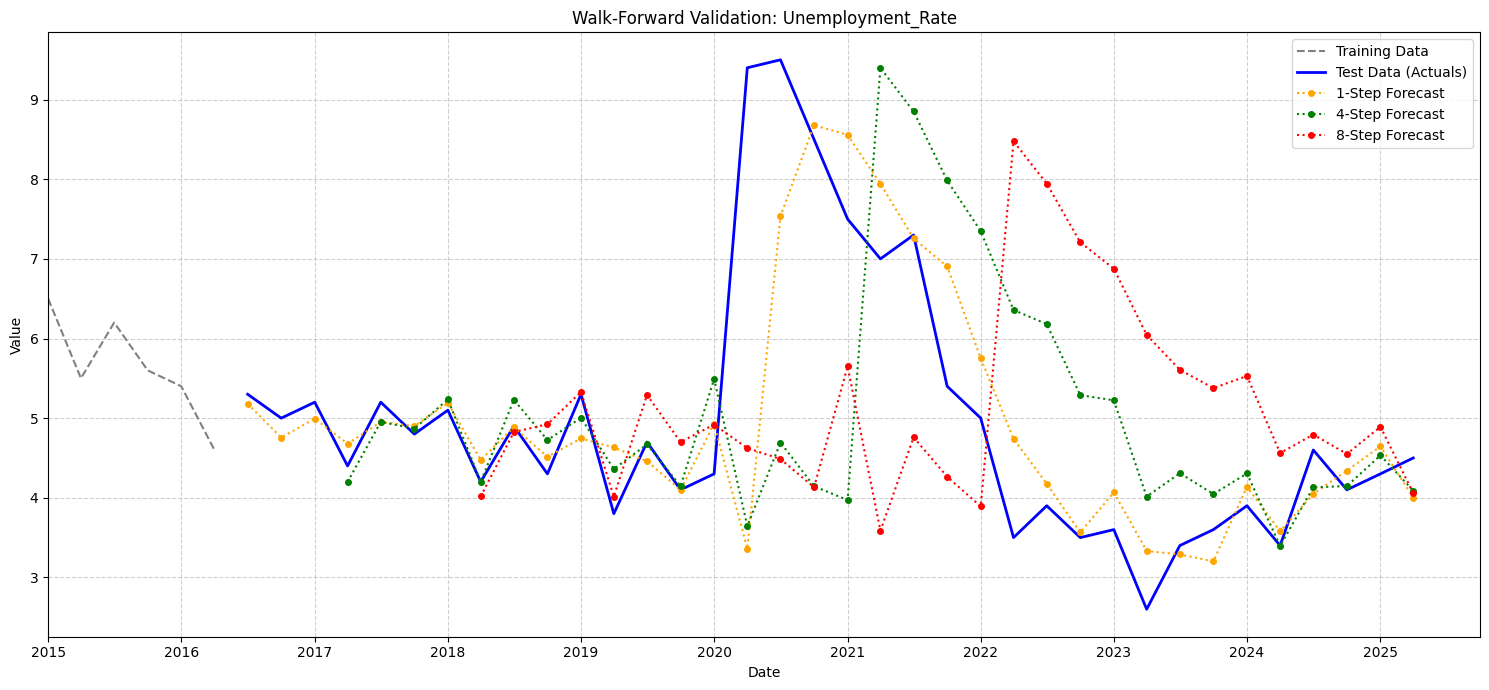


--- Processing Column: Interest_Rate ---
  Train Period: 1990-01-01 to 2016-04-01
  Test Period : 2016-07-01 to 2025-04-01
  Starting walk-forward loop...
  Walk-forward loop finished.
  Calculating metrics...
  Generating visualization...


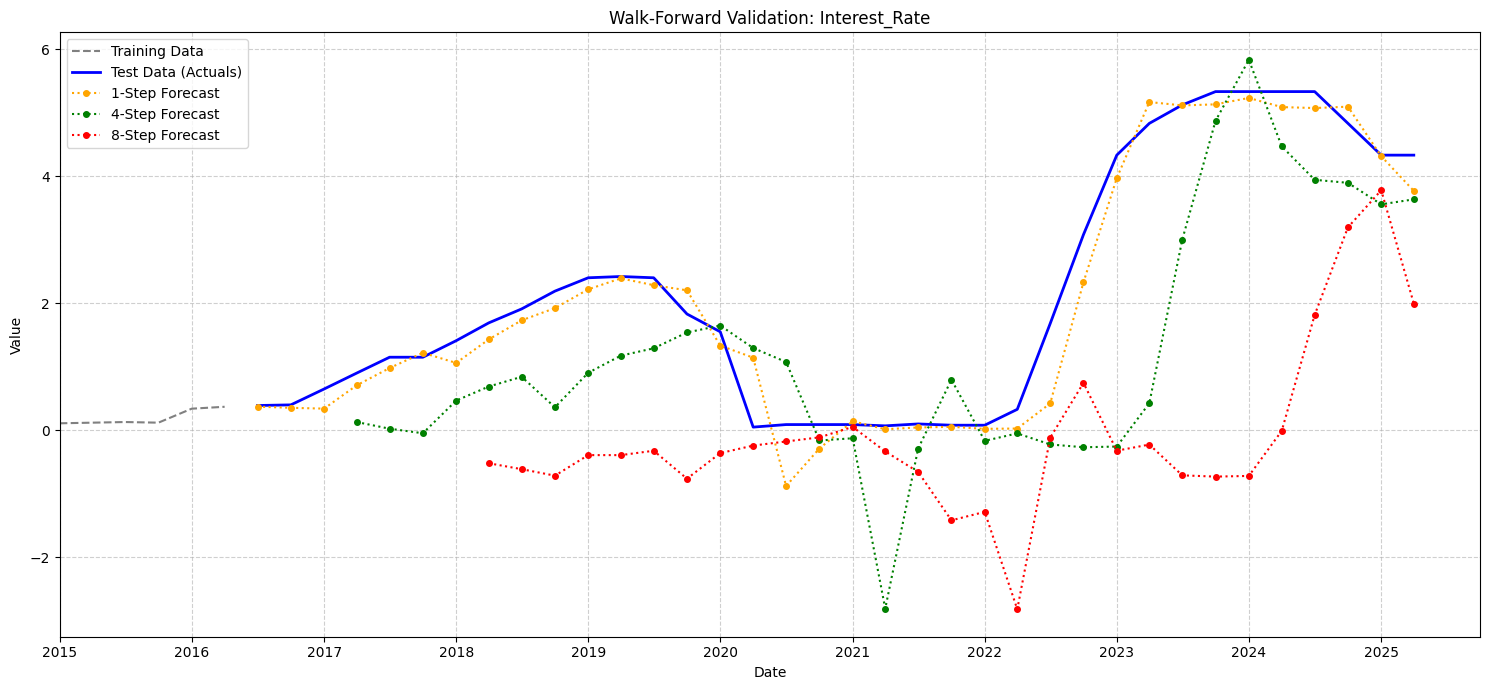


--- Processing Column: Mortgage_Rate ---
  Train Period: 1990-01-01 to 2016-04-01
  Test Period : 2016-07-01 to 2025-04-01
  Starting walk-forward loop...
  Walk-forward loop finished.
  Calculating metrics...
  Generating visualization...


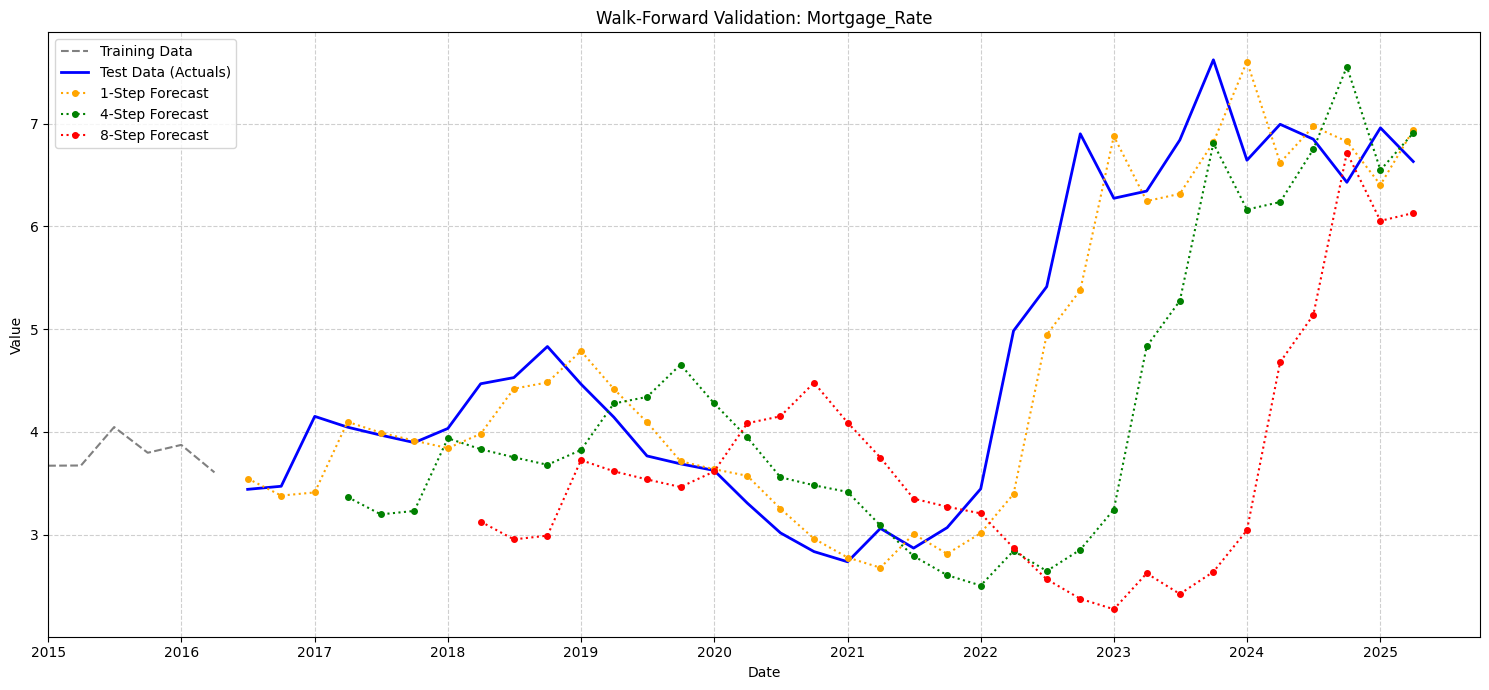


--- Processing Column: CPI ---
  Train Period: 1990-01-01 to 2016-01-01
  Test Period : 2016-04-01 to 2025-01-01
  Starting walk-forward loop...
  Walk-forward loop finished.
  Calculating metrics...
  Generating visualization...


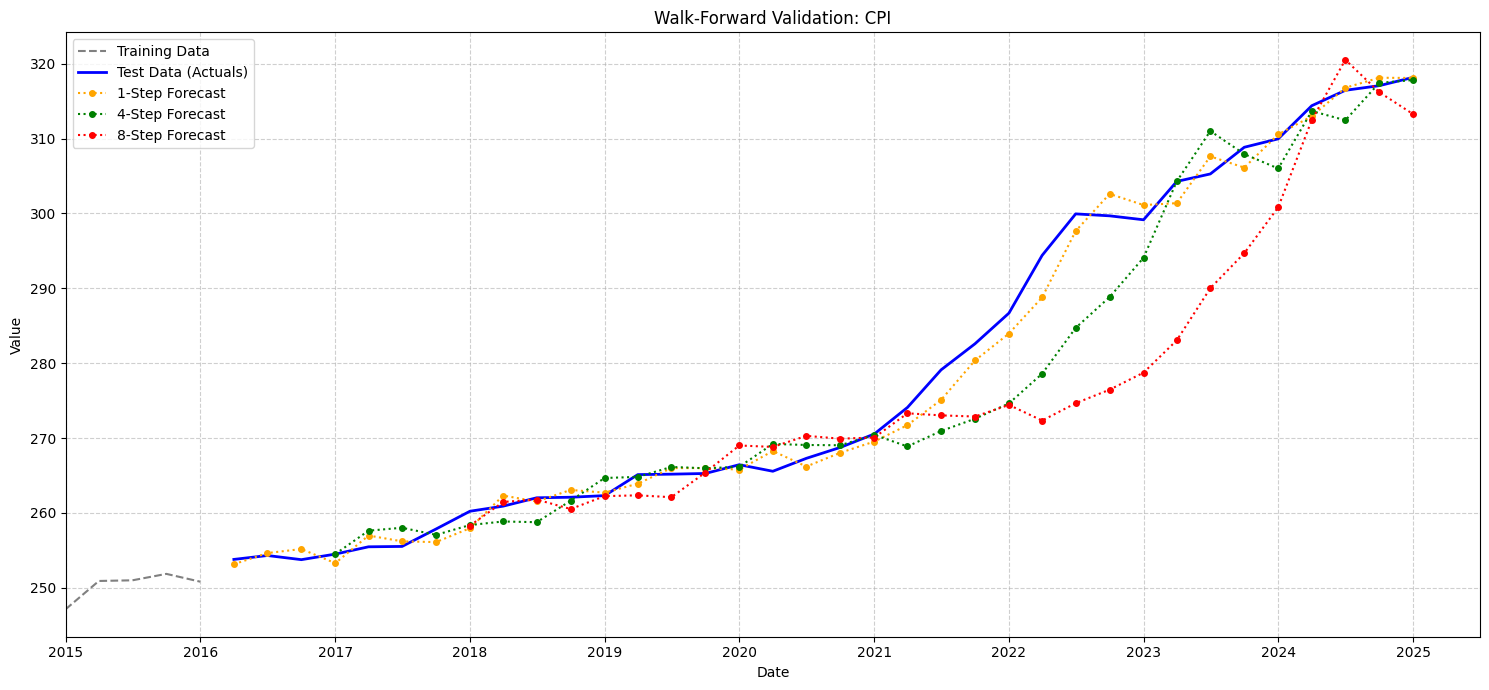


--- Processing Column: House_Index ---
  Train Period: 1990-01-01 to 2015-10-01
  Test Period : 2016-01-01 to 2024-10-01
  Starting walk-forward loop...
  Walk-forward loop finished.
  Calculating metrics...
  Generating visualization...


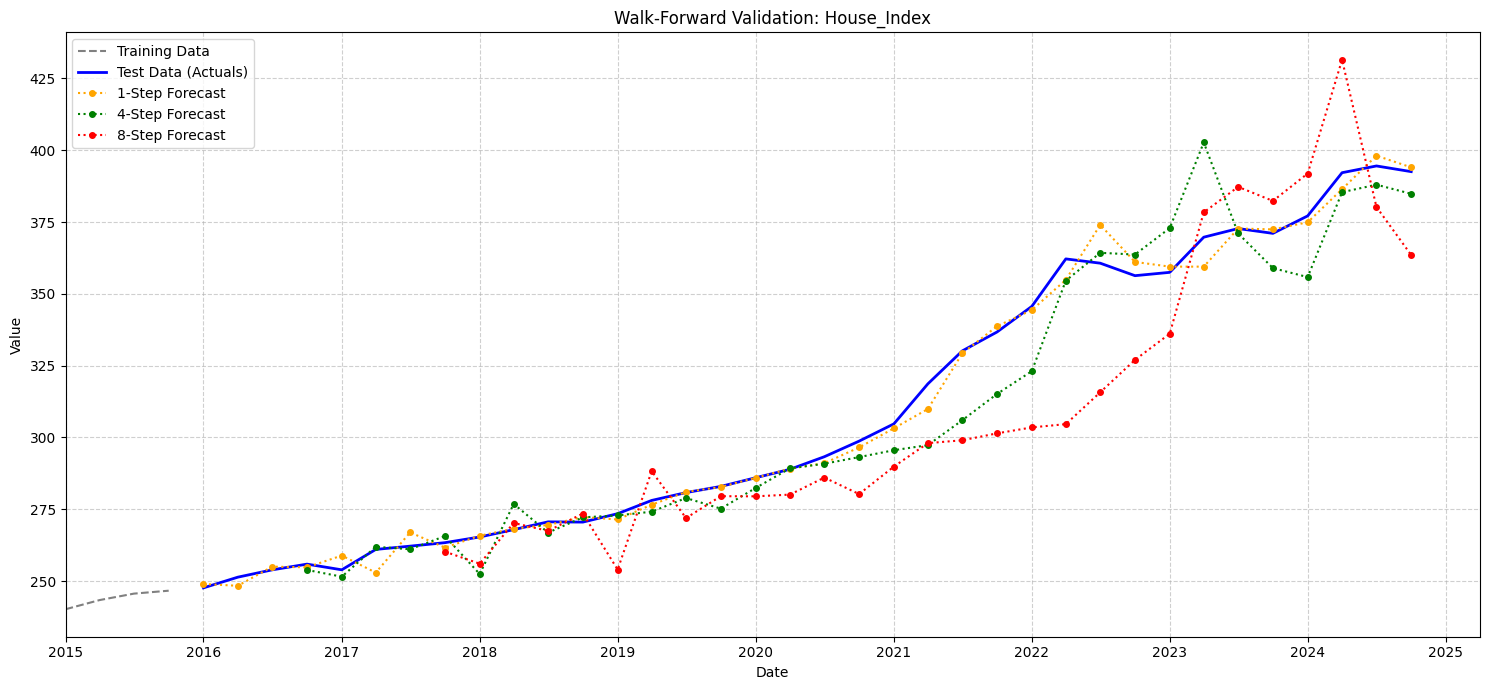


--- Processing Column: GDP ---
  Train Period: 1990-01-01 to 2015-10-01
  Test Period : 2016-01-01 to 2024-10-01
  Starting walk-forward loop...
  Walk-forward loop finished.
  Calculating metrics...
  Generating visualization...


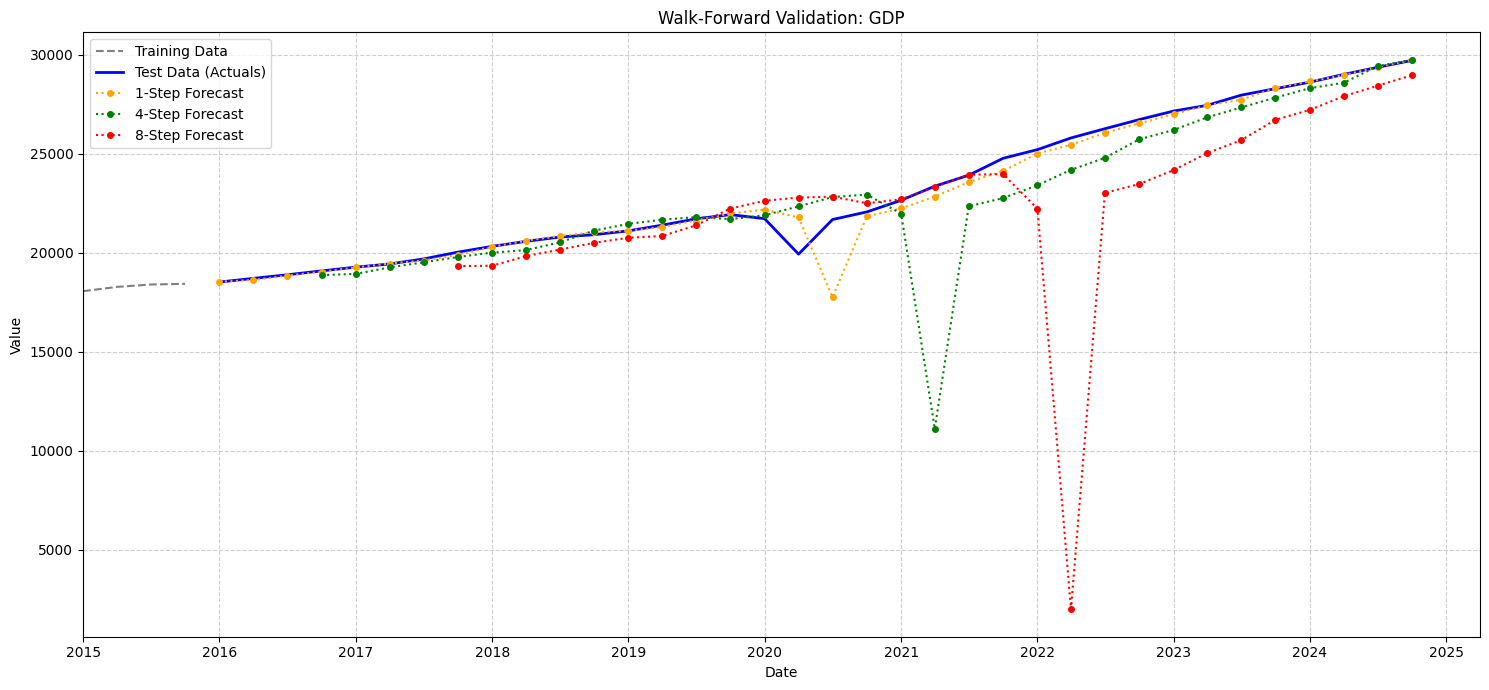


--- Processing Column: Population ---
  Train Period: 1990-01-01 to 2015-07-01
  Test Period : 2015-10-01 to 2024-07-01
  Starting walk-forward loop...
  Walk-forward loop finished.
  Calculating metrics...
  Generating visualization...


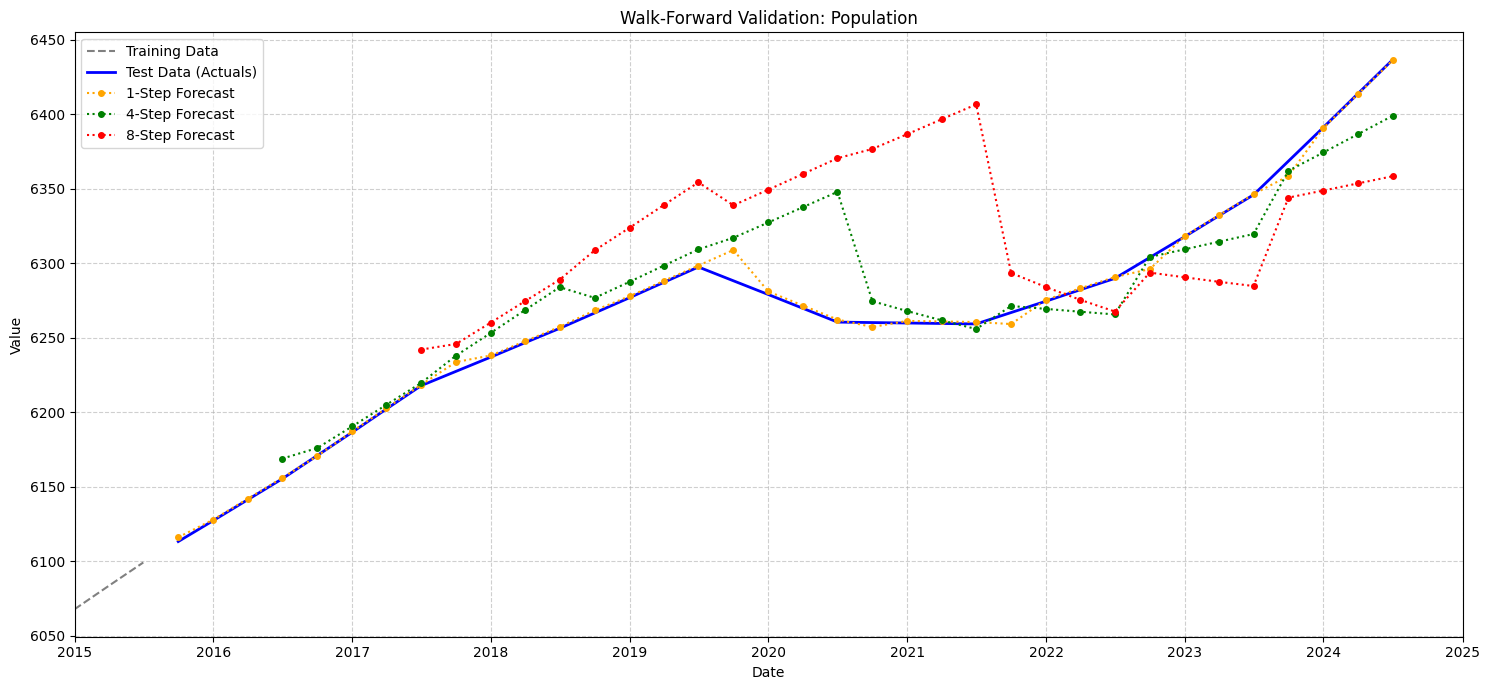


--- Processing Column: Poverty_Rate ---
  Train Period: 1990-01-01 to 2014-01-01
  Test Period : 2014-04-01 to 2023-01-01
  Starting walk-forward loop...
  Walk-forward loop finished.
  Calculating metrics...
  Generating visualization...


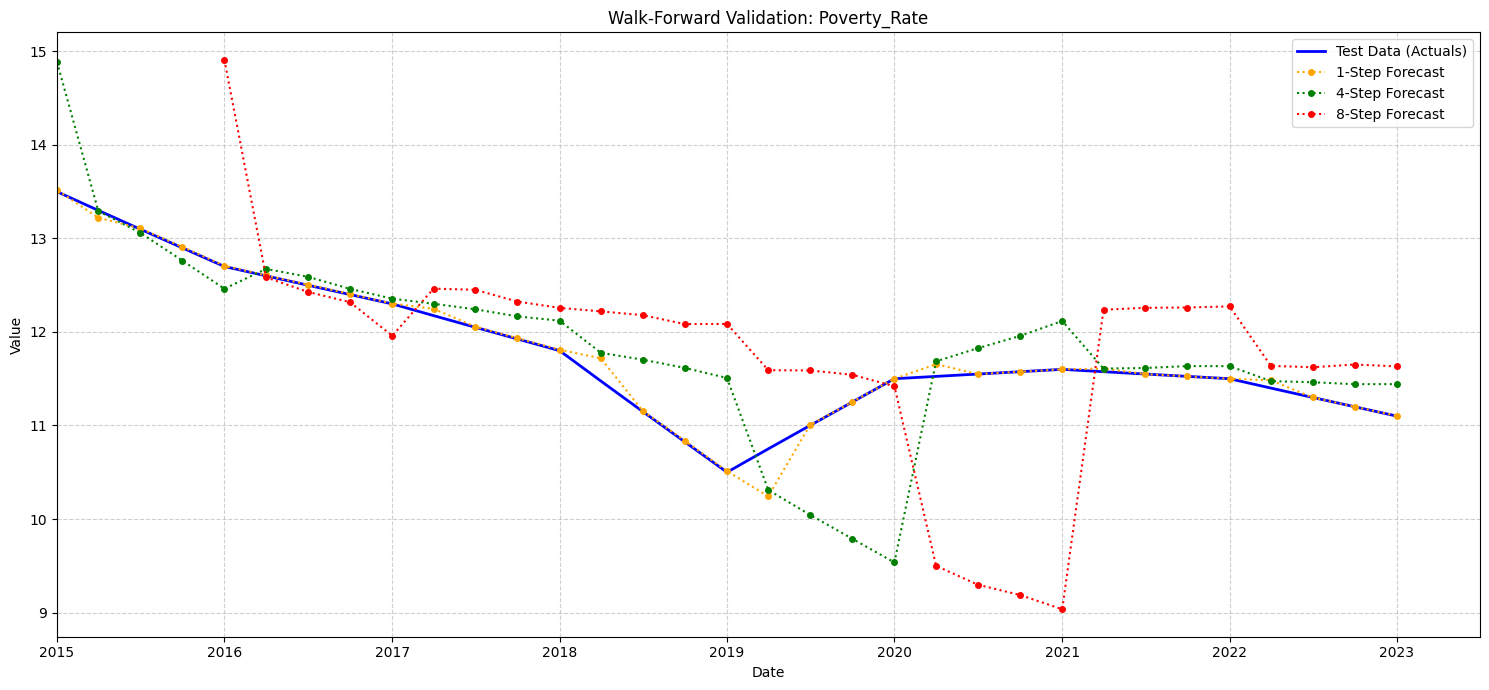


--- Processing Column: Median_Household_Income ---
  Train Period: 1990-01-01 to 2014-01-01
  Test Period : 2014-04-01 to 2023-01-01
  Starting walk-forward loop...
  Walk-forward loop finished.
  Calculating metrics...
  Generating visualization...


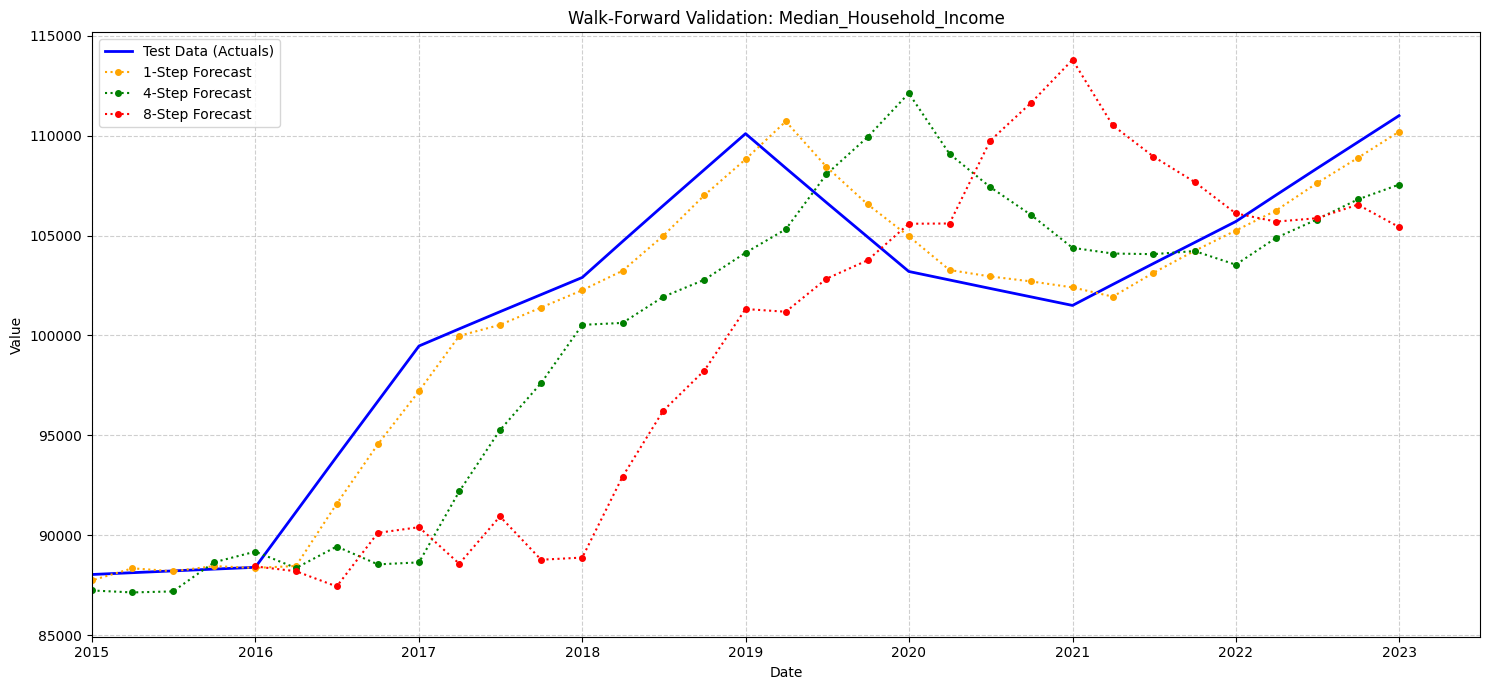

In [8]:
for col_name, model_template in fitted_models.items():
    print(f"\n--- Processing Column: {col_name} ---")

    # 1. Prepare Data
    series = df[col_name].dropna().astype(float) # Ensure series is float for ARIMA
    train_data_initial = series[:-n_test_quarters]
    test_data = series[-n_test_quarters:]
    print(f"  Train Period: {train_data_initial.index.min().strftime('%Y-%m-%d')} to {train_data_initial.index.max().strftime('%Y-%m-%d')}")
    print(f"  Test Period : {test_data.index.min().strftime('%Y-%m-%d')} to {test_data.index.max().strftime('%Y-%m-%d')}")

    # Initialize storage using steps_to_calculate
    predictions = {step: [] for step in steps_to_calculate}
    actuals = {step: [] for step in steps_to_calculate}
    history = {step: [] for step in steps_to_calculate}
    prediction_indices = {step: [] for step in steps_to_calculate}

    order = model_template.order
    seasonal_order = model_template.seasonal_order

# 2. Perform Walk-Forward Validation
    print("  Starting walk-forward loop...")
    for i in range(len(test_data)):
        current_train_end_index = len(train_data_initial) + i
        current_train = series[:current_train_end_index]

        steps_possible = len(test_data) - i
        current_max_forecast = min(max_steps, steps_possible)
        if current_max_forecast <= 0: continue

        try:
            refitted_model = pm.ARIMA(order=order,
                                      seasonal_order=seasonal_order,
                                      suppress_warnings=True).fit(current_train)
            forecasts = refitted_model.predict(n_periods=current_max_forecast, return_conf_int=False)
            last_actual_val = current_train.iloc[-1]

            # Store predictions/actuals using steps_to_calculate
            for step in steps_to_calculate:
                if step <= current_max_forecast:
                    forecast_val = forecasts[step - 1]
                    actual_val_index = current_train_end_index + step - 1
                    actual_val = series.iloc[actual_val_index]
                    actual_val_date = series.index[actual_val_index]

                    predictions[step].append(forecast_val)
                    actuals[step].append(actual_val)
                    history[step].append(last_actual_val)
                    prediction_indices[step].append(actual_val_date)

        except Exception as e:
             print(f"  Error fitting/predicting at step {i} for {col_name}: {e}")
             continue
    print("  Walk-forward loop finished.")
    all_column_predictions[col_name] = {
         'preds': predictions,
         'actuals': actuals,
         'indices': prediction_indices
    }


    # 3. Calculate Metrics using steps_to_calculate
    print("  Calculating metrics...")
    metrics_summary = {}
    for step in steps_to_calculate: # Use steps_to_calculate here
        preds_step = predictions[step]
        actuals_step = actuals[step]
        history_step = history[step]

        if len(preds_step) > 0 and len(preds_step) == len(actuals_step) and len(preds_step) == len(history_step):
             rmse = np.sqrt(mean_squared_error(actuals_step, preds_step))
             mae = mean_absolute_error(actuals_step, preds_step)
             mape = mean_absolute_percentage_error(actuals_step, preds_step)
             dacc = directional_accuracy(actuals_step, preds_step, history_step)
             metrics_summary[f'{step}-Step'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'Directional Accuracy': dacc, 'Count': len(preds_step)}
        else:
             metrics_summary[f'{step}-Step'] = {'RMSE': np.nan, 'MAE': np.nan, 'MAPE': np.nan, 'Directional Accuracy': np.nan, 'Count': 0}
             # Don't warn here unless count is unexpectedly zero for steps that should have been calculated

    all_column_metrics[col_name] = metrics_summary
    # print(f"  Metrics for {col_name}: {metrics_summary}") # Optional: Print detailed metrics per column


    # 4. Visualize Results using steps_to_plot
    print("  Generating visualization...")
    fig, ax = plt.subplots(figsize=(15, 7))
    viz_start_date = pd.Timestamp('2015-01-01')
    train_to_plot = train_data_initial[train_data_initial.index >= viz_start_date]
    if not train_to_plot.empty:
         ax.plot(train_to_plot.index, train_to_plot, label='Training Data', color='grey', linestyle='--')
    ax.plot(test_data.index, test_data, label='Test Data (Actuals)', color='blue', linewidth=2)

    colors = {1: 'orange', 4: 'green', 8: 'red'}
    for step in steps_to_plot:
         if step in predictions and len(prediction_indices[step]) > 0: # Check if step exists and has data
              pred_series = pd.Series(data=predictions[step], index=prediction_indices[step])
              ax.plot(pred_series.index, pred_series, label=f'{step}-Step Forecast', color=colors.get(step, 'black'), marker='o', linestyle=':', markersize=4)

    ax.set_title(f'Walk-Forward Validation: {col_name}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(left=viz_start_date, right=test_data.index.max() + pd.DateOffset(months=6))
    plt.tight_layout()
    plt.show()

### Report Overall Metrics

In [9]:
# Delete all deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("\n--- Walk-Forward Validation Metrics Summary (Steps 1-8) ---")
metrics_df_list = []
for col_name, metrics in all_column_metrics.items():
     for step_key, step_metrics in metrics.items():
          step_metrics['Column'] = col_name
          step_metrics['Step'] = step_key
          metrics_df_list.append(step_metrics)

metrics_df = pd.DataFrame(metrics_df_list)
# Ensure Step column is suitable for sorting if needed (e.g., extract number)
metrics_df['Step_Num'] = metrics_df['Step'].str.extract('(\d+)').astype(int)
metrics_df = metrics_df.set_index(['Column', 'Step_Num'])[['RMSE', 'MAE', 'MAPE', 'Directional Accuracy']]
metrics_df = metrics_df.sort_index() # Sort by column then step number
print(metrics_df.to_string(float_format="%.3f"))


--- Walk-Forward Validation Metrics Summary (Steps 1-8) ---
                                     RMSE      MAE    MAPE  Directional Accuracy
Column                  Step_Num                                                
CPI                     1           1.969    1.599   0.569                86.111
                        2           3.301    2.257   0.798                94.286
                        3           4.528    3.081   1.078               100.000
                        4           5.732    3.696   1.288               100.000
                        5           7.122    4.602   1.591               100.000
                        6           8.399    5.553   1.903               100.000
                        7           9.623    6.281   2.139               100.000
                        8          10.873    7.316   2.474               100.000
GDP                     1         754.552  298.853   1.350                91.667
                        2        1243.774  529.0

# 7. Visualize SARIMA Forecast for House Price Index

We got a lot of information, and see how ARIMA works really well for all the variables at least in the short term. We see the errors accumulate over longer steps, and the Covid period definitely increased the error margins in the models. We can expect relatively high predictive power given no catastrophic events in the short term future though. Let's visualize the forecasts and the confidence intervals on the housing price index again.


--- Generating Forecast Plot for: House_Index ---
Generating 8-step ahead forecast from 2024-10-01...

--- Forecasts for House_Index ---
              Forecast  Lower 95% CI  Upper 95% CI
2025-01-01  397.595329    391.774654    403.416005
2025-04-01  406.950854    395.965339    417.936369
2025-07-01  408.671503    393.274223    424.068784
2025-10-01  407.948235    387.724247    428.172224
2026-01-01  412.088262    385.580685    438.595839
2026-04-01  419.200874    386.262156    452.139593
2026-07-01  421.035745    382.201594    459.869896
2026-10-01  421.181215    376.461115    465.901315


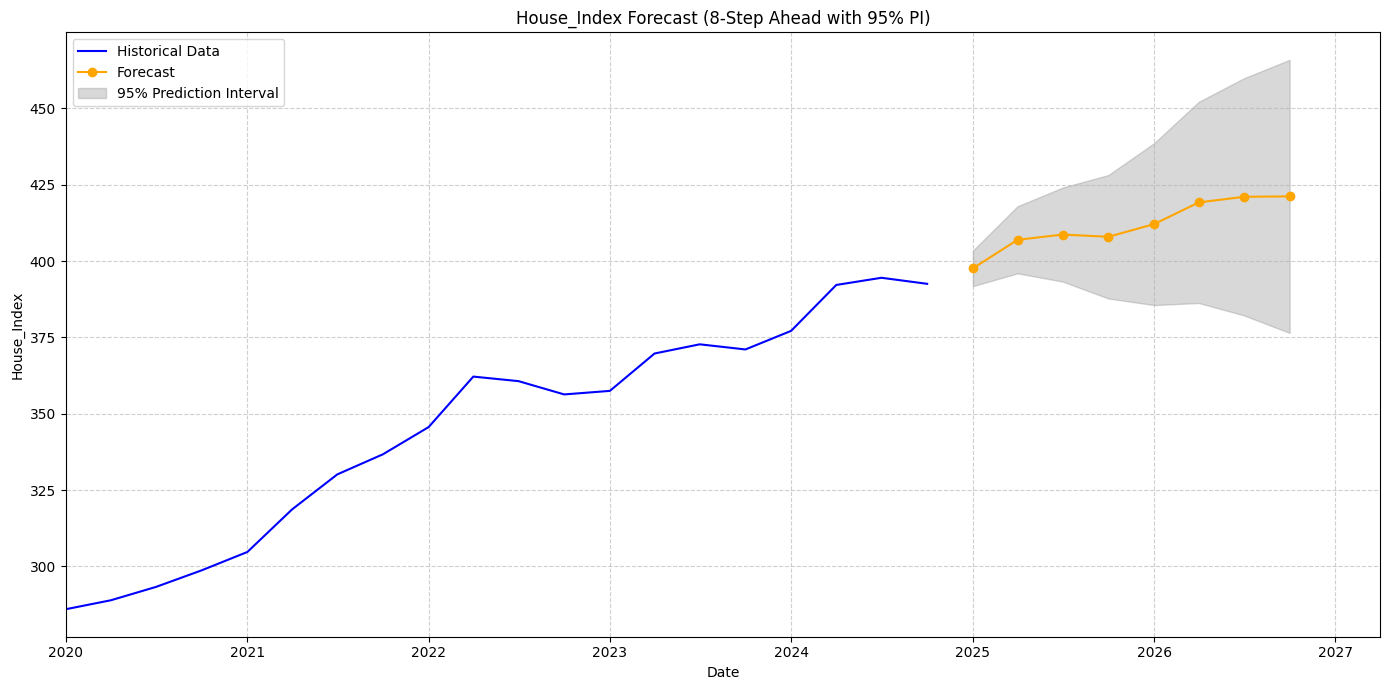

In [10]:
# 1. Get Data and Model
col_name = 'House_Index'
print(f"\n--- Generating Forecast Plot for: {col_name} ---")

if col_name not in fitted_models:
    print(f"Error: Model for {col_name} not found in fitted_models.")
else:
    # Get the original series (dropping NaNs to find the end point)
    house_index_series = df[col_name].dropna().astype(float)
    last_date = house_index_series.index.max()

    # Get the pre-fitted model
    model_to_forecast = fitted_models[col_name]

    # 2. Generate Forecasts
    n_steps = 8 # Forecast 8 quarters ahead
    print(f"Generating {n_steps}-step ahead forecast from {last_date.strftime('%Y-%m-%d')}...")

    # Use predict with return_conf_int=True
    # alpha=0.05 corresponds to a 95% confidence interval
    point_forecasts, conf_int = model_to_forecast.predict(n_periods=n_steps,
                                                          return_conf_int=True,
                                                          alpha=0.05)

    # 3. Create Forecast DataFrame with Correct Index
    # Generate the date index for the forecast period
    forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=n_steps, freq='QS')

    # Combine forecasts and confidence intervals
    forecast_df = pd.DataFrame({
        'Forecast': point_forecasts,
        'Lower 95% CI': conf_int[:, 0], # Lower bound is the first column
        'Upper 95% CI': conf_int[:, 1]  # Upper bound is the second column
    }, index=forecast_index) # Assign the correct index directly

    print("\n--- Forecasts for House_Index ---")
    print(forecast_df)

    # 4. Visualize the Forecast
    plt.figure(figsize=(14, 7))

    # Plot historical data (optional: limit start date for clarity)
    viz_start_date_hist = pd.Timestamp('2020-01-01') # Start historical plot from 2015
    plt.plot(house_index_series[house_index_series.index >= viz_start_date_hist], label='Historical Data', color='blue')

    # Plot point forecasts
    plt.plot(forecast_df['Forecast'], label='Forecast', color='orange', marker='o')

    # Plot confidence interval
    plt.fill_between(forecast_df.index,
                     forecast_df['Lower 95% CI'],
                     forecast_df['Upper 95% CI'],
                     color='gray', alpha=0.3, label='95% Prediction Interval') # Changed alpha slightly

    # Set x-axis limits - start from 2015 to see recent history and forecast
    plt.xlim(left=viz_start_date_hist, right=forecast_df.index[-1] + pd.DateOffset(months=6))

    # Add titles and labels
    plt.title(f'{col_name} Forecast ({n_steps}-Step Ahead with 95% PI)')
    plt.xlabel('Date')
    plt.ylabel(col_name)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


# 8. Summary and autoarima Conclusion

The auto_arima function successfully identified and fitted appropriate SARIMA models for the diverse set of quarterly DC economic indicators, capturing various levels of trend and seasonality across the time series. These baseline models proved useful not only for understanding the historical patterns but also for practical applications like forecasting to fill missing data points, creating a complete dataset extending to early 2027. 

The rigorous walk-forward validation provided valuable insights into the models' predictive performance at different horizons. As expected, forecast accuracy generally decreased for longer forecast steps (1-step vs. 8-step), evidenced by increasing RMSE and MAE values for most indicators. Directional accuracy also tended to decline over longer horizons, highlighting the increasing challenge of predicting market turns further out. Some indicators, like Mortgage Rate (with a simpler ARIMA(0,1,0) model), appeared relatively easier to forecast in the short term compared to more complex series like GDP (ARIMA(0,2,1)). 

The specific forecast for the House Price Index projected a continued, albeit potentially slowing, upward trend over the next two years, though the widening prediction interval underscored the inherent uncertainty in longer-range housing market predictions. Overall, this SARIMA analysis establishes a quantitative baseline for forecasting these DC economic indicators and understanding the associated forecast reliability.

Next, we will formally confirm some of autoarima's findings, then do feature engineering.

In [14]:
# Save csv with filled values
df_filled_to_save = df_filled.reset_index(names = 'Date')
df_filled_to_save.to_csv('DC_Master_ARIMA_Filled.csv', index=False)